In [1]:
import sys
sys.path.append('/Users/aidanmorson/Desktop/analysis/parkinsons/analysis')


In [2]:
import os
from load_data.load_npz import load_spikedata
from analysis.position_sd import get_neuron_positions
from analysis.firing_sd import mean_firing_rates
import numpy as np
import matplotlib.pyplot as plt

In [3]:
sd24578_49 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d49/24578_D49-6.zip')
sd24578_60 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d60/24578_D60+6.zip')
sd24481_49 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d49/24481_D49-6.zip')
sd24481_60 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d60/24481_D60+6.zip')

In [4]:
acg24481_49_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d49/24481_SmitsMO_D49_sect300_20241031_params_bin200us_ccg50_lat10_p00001_conn/acg.npz'
fc24481_49_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d49/24481_SmitsMO_D49_sect300_20241031_params_bin200us_ccg50_lat10_p00001_conn/func_pairs.npz'
acg24578_49_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d49/24578_SmitsMO_D49_sect300_20241031_params_bin200us_ccg50_lat10_p00001_conn/acg.npz'
fc24578_49_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d49/24578_SmitsMO_D49_sect300_20241031_params_bin200us_ccg50_lat10_p00001_conn/func_pairs.npz'
acg24481_60_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d60/24481_SmitsMO_D60_sect300_Control_DIV6_20241112_params_bin200us_ccg50_lat10_p00001_conn/acg.npz'
fc24481_60_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d60/24481_SmitsMO_D60_sect300_Control_DIV6_20241112_params_bin200us_ccg50_lat10_p00001_conn/func_pairs.npz'
acg24578_60_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d60/24578_SmitsMO_D60_sect300_T2PostDrug175-DIV6_20241112_params_bin200us_ccg50_lat10_p00001_conn/acg.npz' 
fc24578_60_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d60/24578_SmitsMO_D60_sect300_T2PostDrug175-DIV6_20241112_params_bin200us_ccg50_lat10_p00001_conn/func_pairs.npz'

In [5]:
acg24481_49 = np.load(acg24481_49_path, allow_pickle=True)
fc24481_49 = np.load(fc24481_49_path, allow_pickle=True)
acg24578_49 = np.load(acg24578_49_path, allow_pickle=True)
fc24578_49 = np.load(fc24578_49_path, allow_pickle=True)
acg24481_60 = np.load(acg24481_60_path, allow_pickle=True)
fc24481_60 = np.load(fc24481_60_path, allow_pickle=True)
acg24578_60 = np.load(acg24578_60_path, allow_pickle=True)
fc24578_60 = np.load(fc24578_60_path, allow_pickle=True)


In [6]:
ac24481_49 = acg24481_49['acg_dict'].item()
ac24481_60 = acg24481_60['acg_dict'].item()
ac24578_49 = acg24578_49['acg_dict'].item()
ac24578_60 = acg24578_60['acg_dict'].item()

In [7]:
fp24481_49 = fc24481_49['func_pairs'].item()
fp24481_60 = fc24481_60['func_pairs'].item()
fp24578_49 = fc24578_49['func_pairs'].item()
fp24578_60 = fc24578_60['func_pairs'].item()


In [9]:
pairs24481_49 = list(fp24481_49.keys())
pairs24481_60 = list(fp24481_60.keys())
pairs24578_49 = list(fp24578_49.keys())
pairs24578_60 = list(fp24578_60.keys())


In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from analysis.position_sd import get_neuron_positions, pair_distances
import matplotlib.lines as mlines

def plot_overlapping_wave_footprint(
    sd, sender_id, receiver_id, ax=None, 
    mean_fr_sender=None, mean_fr_receiver=None, 
    ylim_margin=0.0
):
    """
    Overlap the waveform footprint for two neurons (sender in red, receiver in blue)
    on the same axis. Adds a legend with each neuron's position and mean firing rate,
    plus a dummy entry for the separation between the two neurons.
    
    Parameters:
      sd : SpikeData object
          Must have neuron_attributes with keys:
            - "channel"
            - "position"
            - "neighbor_channels"
            - "neighbor_positions"
            - "neighbor_templates"
        Each key is an array/list, indexed by neuron ID.
      sender_id : int
      receiver_id : int
      ax : matplotlib.axes.Axes, optional
          The axis to draw on. If None, a new figure/axis is created.
      mean_fr_sender : float, optional
          Mean firing rate for sender (Hz).
      mean_fr_receiver : float, optional
          Mean firing rate for receiver (Hz).
      ylim_margin : float, optional
          Additional margin for the y-limits in the inset wave plots.
    
    Returns:
      ax : matplotlib.axes.Axes
          The axis containing the overlaid footprints.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))
    
    data = sd.neuron_attributes
    
    # A helper function to plot one neuron's footprint
    def plot_footprint_for_one(neuron_id, color, fr=None):
        ch = data["channel"][neuron_id]
        position = data["position"][neuron_id]
        temp_chs = list(data["neighbor_channels"][neuron_id])
        temp_pos = data["neighbor_positions"][neuron_id]
        templates = data["neighbor_templates"][neuron_id]
        
        if color == 'red':
            tag = 'Sender'
        else:
            tag = 'Receiver'

        # Build legend label for this neuron.
        scatter_label = f"{neuron_id} ({tag}): ({position[0]:.1f}, {position[1]:.1f})"
        if fr is not None:
            scatter_label += f", {fr:.1f} Hz"

        # Plot the main neuron as a colored dot with a legend entry.
        ax.scatter(position[0], position[1], s=100, alpha=0.3, color=color,
                   label=scatter_label)
        
        # neighbor checks
        if ch in temp_chs:
            idx_main = temp_chs.index(ch)
            wave_main = templates[idx_main]
        else:
            idx_main = 0
            wave_main = templates[0]
        ylim_min = wave_main.min()
        ylim_max = wave_main.max()

        pitch = 17.5
        nelec = 2
        for i in range(len(temp_chs)):
            chn_pos = temp_pos[i]
            # check if neighbor is within a bounding box
            if (position[0] - nelec * pitch <= chn_pos[0] <= position[0] + nelec * pitch and
                position[1] - nelec * pitch <= chn_pos[1] <= position[1] + nelec * pitch):
                # create an inset axis (enlarged for visibility)
                ax_inset = ax.inset_axes([chn_pos[0]-6, chn_pos[1]-6, 25, 25], transform=ax.transData)
                ax_inset.plot(templates[i], color=color, linewidth=1, alpha=0.9)
                ax_inset.set_ylim([ylim_min - ylim_margin, ylim_max + ylim_margin])
                ax_inset.set_axis_off()

        # Connect lines from main neuron to neighbors
        for pos in temp_pos:
            if (position[0] - nelec * pitch <= pos[0] <= position[0] + nelec * pitch and
                position[1] - nelec * pitch <= pos[1] <= position[1] + nelec * pitch):
                ax.plot([position[0], pos[0]], [position[1], pos[1]], color='gray', linestyle='--', alpha=0.4)
        
        return position

    # Plot the sender in red
    pos_sender = plot_footprint_for_one(sender_id, 'red', mean_fr_sender)
    # Plot the receiver in blue
    pos_receiver = plot_footprint_for_one(receiver_id, 'blue', mean_fr_receiver)
    
    # Expand axis limits to include both main positions
    pitch = 17.5
    nelec = 2
    x_min = min(pos_sender[0], pos_receiver[0]) - 1.5 * nelec * pitch
    x_max = max(pos_sender[0], pos_receiver[0]) + 1.5 * nelec * pitch
    y_min = min(pos_sender[1], pos_receiver[1]) - 1.5 * nelec * pitch
    y_max = max(pos_sender[1], pos_receiver[1]) + 1.5 * nelec * pitch
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.invert_yaxis()
    ax.set_xlabel("Horizontal Position (µm)", fontsize=9)
    ax.set_ylabel("Vertical Position (µm)", fontsize=9)
    
    # Add the legend for the scatter calls.
    handles, labels = ax.get_legend_handles_labels()
    
    # Compute the separation between the two neurons using pair_distances
    positions = get_neuron_positions(sd)  # Full positions array.
    separation = pair_distances([(sender_id, receiver_id)], positions)[0]
    # Create a dummy legend handle for the separation
    sep_handle = mlines.Line2D([], [], color='none', label=f"Separation: {separation:.1f} µm")
    
    handles.append(sep_handle)
    labels.append(sep_handle.get_label())
    ax.legend(handles, labels, loc='best', fontsize=8)
    
    return ax


def plot_pair_overlapping_wave_and_ccg(
    sd, sender_id, receiver_id, ccg_directory, output_path=None, ylim_margin=0.0
):
    """
    Creates a two-panel figure:
      Left: Overlapping wave footprints for sender (red) and receiver (blue)
      Right: The CCg image from ccg_unit_{sender_id}_{receiver_id}.png

    Parameters:
      sd : SpikeData object
      sender_id : int
      receiver_id : int
      ccg_directory : str
      output_path : str or None
      ylim_margin : float
    """
    from analysis.firing_sd import mean_firing_rates
    fr_array = mean_firing_rates(sd)
    fr_sender = fr_array[sender_id]
    fr_receiver = fr_array[receiver_id]

    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12,6))

    # Plot overlapping wave footprints on ax_left
    plot_overlapping_wave_footprint(
        sd, sender_id, receiver_id, 
        ax=ax_left,
        mean_fr_sender=fr_sender,
        mean_fr_receiver=fr_receiver,
        ylim_margin=ylim_margin
    )
    ax_left.set_title(f"Overlapping Waveforms: {sender_id} (red) & {receiver_id} (blue)", fontsize=10)
    
    # Load the CCg image on ax_right
    ccg_filename = f"ccg_unit_{sender_id}_{receiver_id}.png"
    ccg_path = os.path.join(ccg_directory, ccg_filename)
    if os.path.exists(ccg_path):
        ccg_img = plt.imread(ccg_path)
        ax_right.imshow(ccg_img)
        ax_right.axis('off')
        ax_right.set_title("CCG")
    else:
        ax_right.text(0.5, 0.5, "CCG image not found",
                      horizontalalignment='center', verticalalignment='center')
        ax_right.axis('off')
        ax_right.set_title("CCG Not Found")

    plt.suptitle(f"Pair {sender_id} - {receiver_id}", fontsize=14)
    plt.tight_layout()

    if output_path:
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        filename = f"overlap_wave_ccg_{sender_id}_{receiver_id}.png"
        save_path = os.path.join(output_path, filename)
        fig.savefig(save_path)
        plt.close(fig)
        print(f"Saved 2-panel overlapping wave + CCG figure to {save_path}")
    else:
        plt.show()


def plot_multiple_pairs_overlapping_wave_and_ccg(sd, pairs, ccg_directory, output_path=None, ylim_margin=0.0):
    """
    Loop over a list of (sender, receiver) pairs and produce the overlapping wave footprints
    plus CCg figure for each pair, saving or showing them.
    """
    for (sender_id, receiver_id) in pairs:
        plot_pair_overlapping_wave_and_ccg(
            sd, sender_id, receiver_id, ccg_directory,
            output_path=output_path, ylim_margin=ylim_margin
        )


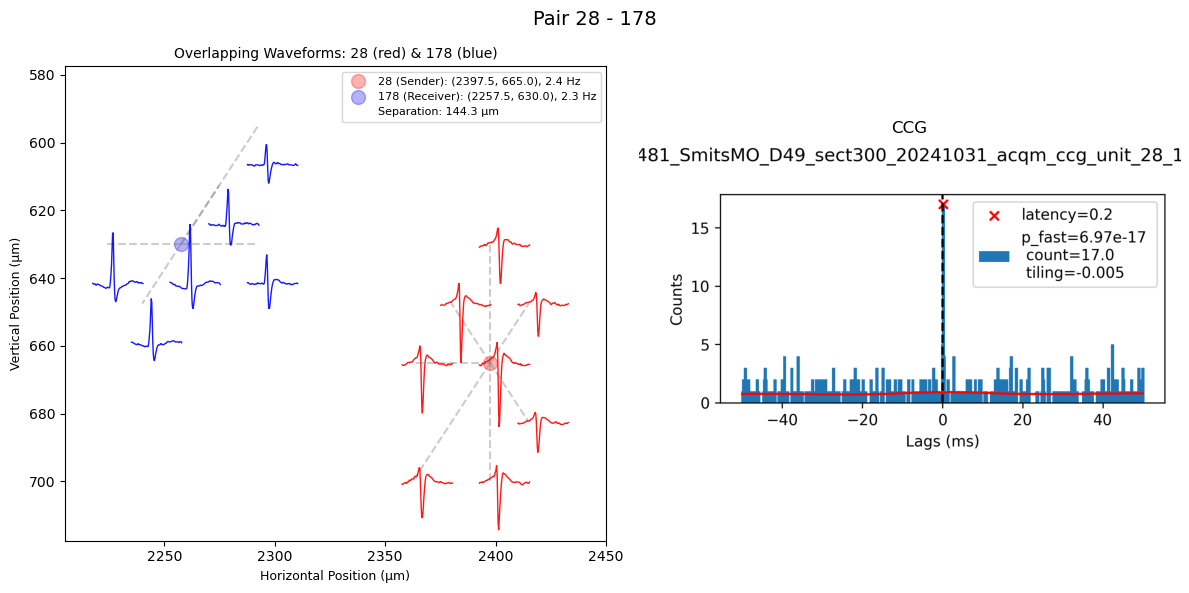

In [11]:
plot_pair_overlapping_wave_and_ccg(sd24481_49, 28, 178, '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d49/24481_SmitsMO_D49_sect300_20241031_params_bin200us_ccg50_lat10_p00001_conn/figures/ccg')

In [12]:
#plot_multiple_pairs_overlapping_wave_and_ccg(sd24481_49, pairs24481_49, '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d49/24481_SmitsMO_D49_sect300_20241031_params_bin200us_ccg50_lat10_p00001_conn/figures/ccg', output_path='aidanmorson/Desktop/analysis/parkinsons/functional-connectivity/waveform-ccg/d49/24481/')
#plot_multiple_pairs_overlapping_wave_and_ccg(sd24481_60, pairs24481_60, '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d60/24481_SmitsMO_D60_sect300_Control_DIV6_20241112_params_bin200us_ccg50_lat10_p00001_conn/figures/ccg', output_path='/Users/aidanmorson/Desktop/analysis/parkinsons/functional-connectivity/waveform-ccg/d60/24481/')
#plot_multiple_pairs_overlapping_wave_and_ccg(sd24578_49, pairs24578_49, '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d49/24578_SmitsMO_D49_sect300_20241031_params_bin200us_ccg50_lat10_p00001_conn/figures/ccg', output_path='/Users/aidanmorson/Desktop/analysis/parkinsons/functional-connectivity/waveform-ccg/d49/24578/')
#plot_multiple_pairs_overlapping_wave_and_ccg(sd24578_60, pairs24578_60, '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/small-bin-wide-lat/d60/24578_SmitsMO_D60_sect300_T2PostDrug175-DIV6_20241112_params_bin200us_ccg50_lat10_p00001_conn/figures/ccg', output_path='/Users/aidanmorson/Desktop/analysis/parkinsons/functional-connectivity/waveform-ccg/d60/24578/')

In [13]:
def sorted_transmission_dict(func_pairs, output_artifact=False):
    """
    Create a sorted dictionary of functional pairs (keys are pairs, values are p_fast),
    and also return dictionaries with only nonnegative values and, optionally,
    only the negative (artifact) values.
    
    Parameters:
      func_pairs (dict): Functional pairs with each value containing 'p_fast'.
      output_artifact (bool): If True, also return a dictionary with only negative p_fast values.
      
    Returns:
      tuple: (full_dict, positive_dict) or (full_dict, positive_dict, artifact_dict)
        - full_dict: All pairs sorted in ascending order of p_fast.
        - positive_dict: Only pairs with p_fast >= 0.
        - artifact_dict: Only pairs with negative p_fast (if output_artifact is True).
    """
    # Create a list of (pair, p_fast) items from func_pairs.
    pair_p_list = [(pair, info['p_fast']) for pair, info in func_pairs.items()]
    # Sort by p_fast in ascending order.
    pair_p_list.sort(key=lambda x: x[1])
    
    full_dict = {pair: p for pair, p in pair_p_list}
    positive_dict = {pair: p for pair, p in pair_p_list if p > 0}
    if output_artifact:
        artifact_dict = {pair: p for pair, p in pair_p_list if p < 0}
        return full_dict, positive_dict, artifact_dict
    else:
        return full_dict, positive_dict

def subset_sorted_dict(sorted_dict, x):
    """
    Return a subset of the sorted dictionary containing only the first x items.
    
    Parameters:
      sorted_dict (dict): A dictionary sorted by the desired criterion (order preserved).
      x (int): The number of items to include.
      
    Returns:
      dict: A new dictionary with only the first x items.
    """
    # Use list slicing on the keys.
    keys_subset = list(sorted_dict.keys())[:x]
    return {k: sorted_dict[k] for k in keys_subset}

In [14]:
def filter_by_latency(func_pairs, min_latency=3.0, max_latency=8.0):
    """
    Remove pairs whose latency is below min_latency or above max_latency.
    """
    filtered = {}
    for pair, info in func_pairs.items():
        lat = info['latency']
        if lat >= min_latency and lat <= max_latency:
            filtered[pair] = info
    return filtered

In [16]:
fp24481_49_sorted =  filter_by_latency(fp24481_49, min_latency=3.0, max_latency=100)

In [22]:
print(len(fp24481_49_sorted.keys()))
print(len(fp24481_49.keys()))

26
386


In [23]:
print(fp24481_49_sorted.keys())

dict_keys([(1, 36), (3, 18), (23, 287), (24, 25), (32, 386), (42, 386), (45, 321), (52, 202), (79, 249), (84, 212), (86, 285), (96, 225), (99, 152), (101, 384), (110, 148), (118, 276), (122, 238), (135, 140), (144, 145), (160, 331), (162, 283), (170, 270), (177, 194), (188, 248), (243, 271), (297, 346)])
